# House Price Prediction — 03: Model Training

**Goal:** Train and compare 6 regression models, evaluate with regression-appropriate metrics, and select a champion.

**Models compared:**
- Linear Regression
- Ridge
- Lasso
- Random Forest
- Gradient Boosting
- KNN

**Metrics used (regression, not classification):**
- **RMSE** (Root Mean Squared Error) — penalizes large errors more heavily (squares the error before averaging); same units as the target
- **MAE** (Mean Absolute Error) — average absolute error, more robust to outliers, easier to interpret directly ("on average, predictions are off by $X")
- **R²** — proportion of variance in the target explained by the model (0 to 1, higher is better)

**Feature set per model family:**
- **Linear models + KNN** (distance/weighted-sum based, sensitive to scale and skew): use the **scaled** feature set, with raw `MedInc`/`Population` swapped out for their `log1p` versions to reduce skew
- **Tree-based models** (Random Forest, Gradient Boosting — split on thresholds, not distances): use the **unscaled, raw** feature set; scaling doesn't help and log-transformed duplicate columns would just be redundant

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style('whitegrid')
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load Preprocessed Data

In [2]:
def load_pkl(name):
    with open(f'outputs/{name}.pkl', 'rb') as f:
        return pickle.load(f)

X_train = load_pkl('X_train')
X_test = load_pkl('X_test')
X_train_scaled = load_pkl('X_train_scaled')
X_test_scaled = load_pkl('X_test_scaled')
y_train = load_pkl('y_train')
y_test = load_pkl('y_test')

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'Columns: {list(X_train.columns)}')

X_train: (16428, 11), X_test: (4107, 11)
Columns: ['MedInc', 'HouseAge', 'AveRooms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'is_max_house_age', 'bedroom_ratio', 'log_MedInc', 'log_Population']


## 3. Build Per-Model-Family Feature Sets

- **Tree set:** unscaled, drop the `log_*` columns, keep raw `MedInc`/`Population`
- **Linear/KNN set:** scaled, drop raw `MedInc`/`Population`, keep `log_*` versions instead (already scaled, since the scaler was fit after the log columns were created)

In [3]:
log_cols = ['log_MedInc', 'log_Population']
raw_skewed_cols = ['MedInc', 'Population']

# Tree-based models: raw scale, drop the redundant log columns
X_train_tree = X_train.drop(columns=log_cols)
X_test_tree = X_test.drop(columns=log_cols)

# Linear/KNN models: scaled, drop raw skewed columns in favor of log versions
X_train_linear = X_train_scaled.drop(columns=raw_skewed_cols)
X_test_linear = X_test_scaled.drop(columns=raw_skewed_cols)

print('Tree feature set columns:', list(X_train_tree.columns))
print('\nLinear feature set columns:', list(X_train_linear.columns))

Tree feature set columns: ['MedInc', 'HouseAge', 'AveRooms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'is_max_house_age', 'bedroom_ratio']

Linear feature set columns: ['HouseAge', 'AveRooms', 'AveOccup', 'Latitude', 'Longitude', 'is_max_house_age', 'bedroom_ratio', 'log_MedInc', 'log_Population']


## 4. Define Models

Starting with reasonable default hyperparameters — these are **not yet tuned**. Tuning happens in a separate notebook once a promising candidate or two is identified here.

In [4]:
models = {
    'Linear Regression': {
        'model': LinearRegression(),
        'feature_set': 'linear'
    },
    'Ridge': {
        'model': Ridge(alpha=1.0, random_state=42),
        'feature_set': 'linear'
    },
    'Lasso': {
        'model': Lasso(alpha=0.1, random_state=42),
        'feature_set': 'linear'
    },
    'KNN': {
        'model': KNeighborsRegressor(n_neighbors=5),
        'feature_set': 'linear'
    },
    'Random Forest': {
        'model': RandomForestRegressor(
            n_estimators=100, max_depth=None, random_state=42, n_jobs=-1
        ),
        'feature_set': 'tree'
    },
    'Gradient Boosting': {
        'model': GradientBoostingRegressor(
            n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42
        ),
        'feature_set': 'tree'
    },
}

print(f'{len(models)} models defined: {list(models.keys())}')

6 models defined: ['Linear Regression', 'Ridge', 'Lasso', 'KNN', 'Random Forest', 'Gradient Boosting']


## 5. Train & Evaluate All Models

In [5]:
feature_sets = {
    'linear': (X_train_linear, X_test_linear),
    'tree': (X_train_tree, X_test_tree),
}

results = []
fitted_models = {}
predictions = {}

for name, config in models.items():
    model = config['model']
    X_tr, X_te = feature_sets[config['feature_set']]

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Feature Set': config['feature_set'],
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    })

    fitted_models[name] = model
    predictions[name] = y_pred

    print(f'{name:20s} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}')

Linear Regression    | RMSE: 0.6805 | MAE: 0.5094 | R2: 0.6488
Ridge                | RMSE: 0.6805 | MAE: 0.5094 | R2: 0.6488
Lasso                | RMSE: 0.7778 | MAE: 0.5909 | R2: 0.5411
KNN                  | RMSE: 0.5969 | MAE: 0.4057 | R2: 0.7297
Random Forest        | RMSE: 0.4896 | MAE: 0.3193 | R2: 0.8182
Gradient Boosting    | RMSE: 0.5160 | MAE: 0.3561 | R2: 0.7980


## 6. Compare Results

In [6]:
results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
results_df

,Model,Feature Set,RMSE,MAE,R2
0,Random Forest,tree,0.489599,0.319278,0.818161
1,Gradient Boosting,tree,0.516023,0.356075,0.798004
2,KNN,linear,0.596891,0.405734,0.729731
3,Ridge,linear,0.680452,0.509437,0.648762
4,Linear Regression,linear,0.680457,0.509443,0.648758
5,Lasso,linear,0.777796,0.590882,0.541079


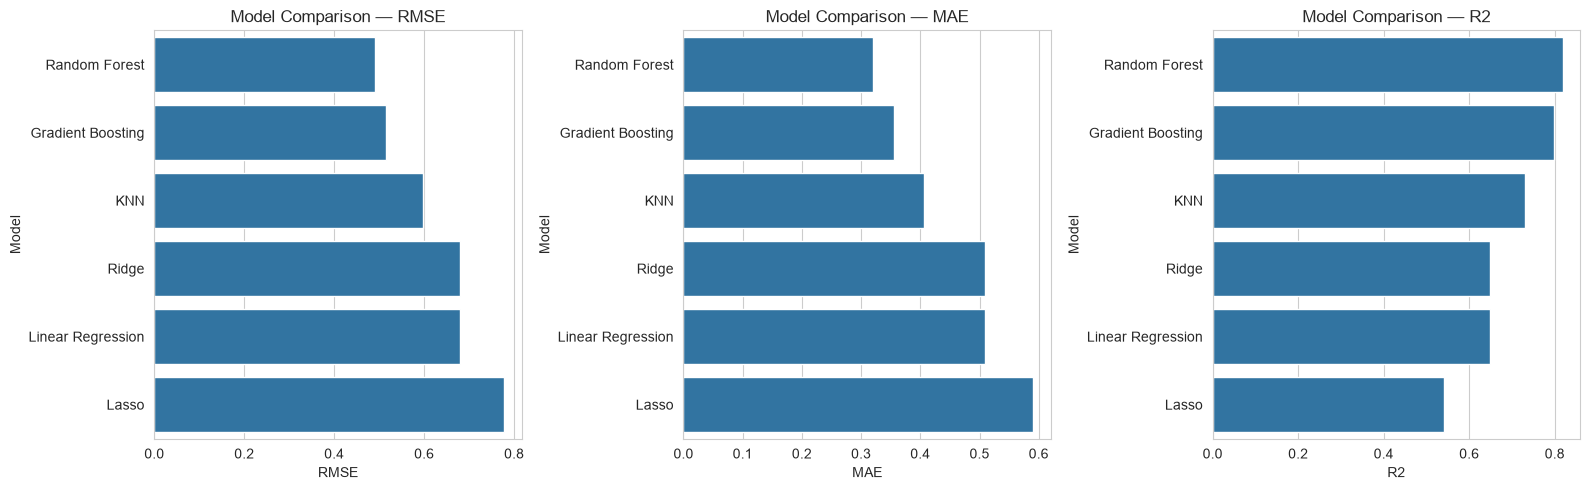

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, ['RMSE', 'MAE', 'R2']):
    sorted_df = results_df.sort_values(metric, ascending=(metric != 'R2'))
    sns.barplot(data=sorted_df, x=metric, y='Model', ax=ax)
    ax.set_title(f'Model Comparison — {metric}')

plt.tight_layout()
plt.savefig('outputs/model_comparison.png', dpi=150)
plt.show()

## 7. Select Champion

In [8]:
champion_name = results_df.iloc[0]['Model']
champion_model = fitted_models[champion_name]
champion_pred = predictions[champion_name]

print(f'Champion model: {champion_name}')
print(results_df[results_df['Model'] == champion_name])

Champion model: Random Forest
           Model Feature Set      RMSE       MAE        R2
0  Random Forest        tree  0.489599  0.319278  0.818161


## 8. Residual Analysis

General residual check, plus a specific check on the rows known to be capped at `MedHouseVal >= 5.0` (identified during EDA/preprocessing) — these rows have an artificially truncated true label, so the model's error on them is expected to look different from the rest of the dataset. This isn't something the model can fix; it's a known dataset limitation, not a modeling flaw.

In [ ]:
residuals = y_test - champion_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(champion_pred, residuals, alpha=0.3)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Value')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title(f'{champion_name} — Residuals vs. Predicted')

sns.histplot(residuals, bins=50, kde=True, ax=axes[1])
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')

plt.tight_layout()
plt.savefig('outputs/residual_analysis.png', dpi=150)
plt.show()

In [ ]:
# Performance specifically on capped vs. non-capped rows
is_capped = (y_test >= 5.0)

for label, subset_mask in [('Capped (>= 5.0)', is_capped), ('Not capped', ~is_capped)]:
    subset_rmse = np.sqrt(mean_squared_error(y_test[subset_mask], champion_pred[subset_mask]))
    subset_mae = mean_absolute_error(y_test[subset_mask], champion_pred[subset_mask])
    print(f'{label:20s} | n={subset_mask.sum():5d} | RMSE: {subset_rmse:.4f} | MAE: {subset_mae:.4f}')

**Expected pattern:** error on the capped subset should be noticeably higher — the model has no way to predict a true value above 5.0 since it never saw a label higher than that during training. This confirms the known limitation flagged during EDA rather than indicating a bug.

## 9. Feature Importance / Coefficients

In [ ]:
champion_feature_set = models[champion_name]['feature_set']
X_champion_train = feature_sets[champion_feature_set][0]

if hasattr(champion_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': X_champion_train.columns,
        'Importance': champion_model.feature_importances_
    }).sort_values('Importance', ascending=False)
elif hasattr(champion_model, 'coef_'):
    importance_df = pd.DataFrame({
        'Feature': X_champion_train.columns,
        'Importance': np.abs(champion_model.coef_)
    }).sort_values('Importance', ascending=False)
else:
    importance_df = None
    print(f'{champion_name} does not expose feature importances or coefficients directly (e.g. KNN).')

if importance_df is not None:
    plt.figure(figsize=(8, 6))
    sns.barplot(data=importance_df, x='Importance', y='Feature')
    plt.title(f'{champion_name} — Feature Importance')
    plt.tight_layout()
    plt.savefig('outputs/feature_importance.png', dpi=150)
    plt.show()
    display(importance_df)

## 10. Save Champion Model & Results

In [ ]:
with open('outputs/champion_model.pkl', 'wb') as f:
    pickle.dump(champion_model, f)

results_df.to_csv('outputs/model_comparison_results.csv', index=False)

if importance_df is not None:
    importance_df.to_csv('outputs/feature_importance.csv', index=False)

print(f'Saved champion model ({champion_name}) and results to outputs/')

## 11. Summary

- **Champion model:** *(fill in after running — whichever model has the lowest RMSE / highest R²)*
- **Key metrics on test set:** *(fill in RMSE / MAE / R²)*
- **Performance gap on capped rows:** *(fill in — confirms the known dataset limitation rather than a modeling issue)*
- **Top features (champion model):** *(fill in from section 9)*
- **Models not yet tuned** — these results reflect default hyperparameters; next step is targeted tuning of the top 1-2 candidates.

**Next notebook:** `04_model_tuning.ipynb` — hyperparameter tuning (e.g. `GridSearchCV` / `RandomizedSearchCV`) on the top-performing model(s) from this comparison, followed by a final evaluation on the test set.